# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

 **Student 1 : Baruh Riss 318739174

 **Student 2 : Amir Ammar 205744873
 
<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from IPython.display import set_matplotlib_formats
%config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torch.distributions as dist

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure reproducibility as much as possible
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)


Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [2]:
def dequantize_mnist(img):
    x = torch.from_numpy(np.array(img, dtype=np.float32)).unsqueeze(0)
    return (x + torch.rand_like(x)) / 256.0

# Continuous representation: add U[0,1] noise to integer pixels, then scale by 256.
transform = transforms.Compose([
    transforms.Lambda(dequantize_mnist),
])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

split_generator = torch.Generator().manual_seed(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000], generator=split_generator)

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 7.19MB/s]


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 190kB/s]


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 1.79MB/s]


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.33MB/s]

Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw

Train size: 50000
Validation size: 10000
Test size: 10000


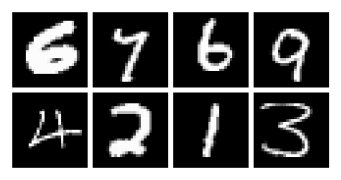

In [3]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

## Task 1

In [6]:
class VAE(nn.Module):

    def __init__(self, latent_dim, decoder_sigma=0.1):
        super().__init__()

        self.latent_dim = latent_dim
        self.decoder_sigma = decoder_sigma

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.encoder_fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_log_std = nn.Linear(128, latent_dim)

        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128 * 7 * 7),
            nn.ReLU(),
        )
        self.decoder_conv = nn.Sequential(
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

        self.logs = defaultdict(list)

    def log(self, key, value):
        self.logs[key].append(value)

    def encode(self, x):
        h = self.encoder(x)
        h = self.encoder_fc(h)
        mu = self.fc_mu(h)
        log_std = self.fc_log_std(h).clamp(min=-6.0, max=2.0)
        std = torch.exp(log_std)
        q_z_given_x = dist.Independent(dist.Normal(mu, std), 1)
        return q_z_given_x, mu, log_std

    def decode(self, z):
        h = self.decoder_fc(z)
        return self.decoder_conv(h)

    def prior(self, batch_size):
        z_loc = torch.zeros(batch_size, self.latent_dim, device=next(self.parameters()).device)
        z_scale = torch.ones_like(z_loc)
        return dist.Independent(dist.Normal(z_loc, z_scale), 1)

    def forward(self, x):
        q_z_given_x, _, _ = self.encode(x)
        z = q_z_given_x.rsample()
        x_mean = self.decode(z)
        return x_mean, q_z_given_x, z

    def calc_elbo(self, batch):
        x_mean, q_z_given_x, _ = self.forward(batch)
        p_x_given_z = dist.Independent(
            dist.Normal(x_mean, torch.full_like(x_mean, self.decoder_sigma)),
            3,
        )
        p_z = self.prior(batch.size(0))

        recon_nll = -p_x_given_z.log_prob(batch).mean()
        kld = dist.kl_divergence(q_z_given_x, p_z).mean()
        negative_elbo = recon_nll + kld
        return negative_elbo, recon_nll, kld

    @torch.no_grad()
    def sample(self, num_samples):
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        return self.decode(z)

    def training_step(self, batch):
        loss, rec_loss, KLD = self.calc_elbo(batch)
        # Log losses
        self.log('train_elbo', loss.item())
        self.log('train_recon', rec_loss.item())
        self.log('train_KLD', KLD.item())
        return loss, rec_loss, KLD

    @torch.no_grad()
    def validation_step(self, loader):
        metric_sums = torch.zeros(3)
        num_examples = 0
        for imgs, _ in tqdm(loader, leave=False):
            imgs = imgs.to(device)
            metrics = torch.stack(self.calc_elbo(imgs)).detach().cpu()
            metric_sums += metrics * imgs.size(0)
            num_examples += imgs.size(0)

        loss, rec_loss, KLD = metric_sums / num_examples
        # Log losses
        self.log('val_elbo', loss.item())
        self.log('val_recon', rec_loss.item())
        self.log('val_KLD', KLD.item())

        return loss

    @torch.no_grad()
    def test_step(self, loader):
        metric_sums = torch.zeros(3)
        num_examples = 0
        for imgs, _ in tqdm(loader, leave=False):
            imgs = imgs.to(device)
            metrics = torch.stack(self.calc_elbo(imgs)).detach().cpu()
            metric_sums += metrics * imgs.size(0)
            num_examples += imgs.size(0)

        loss, rec_loss, KLD = metric_sums / num_examples
        # Log losses
        self.log('test_elbo', loss.item())
        self.log('test_recon', rec_loss.item())
        self.log('test_KLD', KLD.item())

        return loss


### Model Training

In [11]:
latent_dim = 32
model = VAE(latent_dim=latent_dim, decoder_sigma=0.1).to(device)
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.99)


epochs = 100

Num params: 3,553,089


In [12]:
history = defaultdict(list)

# Training loop
for epoch in range(epochs):
    model.train()
    metric_sums = torch.zeros(3)
    num_examples = 0

    for imgs, _ in tqdm(train_loader, leave=False, desc=f"Epoch {epoch + 1}/{epochs}"):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss, rec_loss, KLD = model.training_step(imgs)
        loss.backward()
        optimizer.step()

        batch_metrics = torch.tensor([loss.item(), rec_loss.item(), KLD.item()])
        metric_sums += batch_metrics * imgs.size(0)
        num_examples += imgs.size(0)

    scheduler.step()
    train_loss, train_recon, train_KLD = metric_sums / num_examples
    history['train_elbo'].append(train_loss.item())
    history['train_recon'].append(train_recon.item())
    history['train_KLD'].append(train_KLD.item())

    model.eval()
    val_loss = model.validation_step(val_loader)
    history['val_elbo'].append(model.logs['val_elbo'][-1])
    history['val_recon'].append(model.logs['val_recon'][-1])
    history['val_KLD'].append(model.logs['val_KLD'][-1])

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"train -ELBO: {history['train_elbo'][-1]:.3f} | "
        f"val -ELBO: {history['val_elbo'][-1]:.3f} | "
        f"val recon NLL: {history['val_recon'][-1]:.3f} | "
        f"val KL: {history['val_KLD'][-1]:.3f}"
    )

# Test loop
model.eval()
final_negative_elbo = model.test_step(test_loader)
print(f"Final test negative ELBO: {final_negative_elbo.item():.3f}")
print(f"Final test ELBO: {-final_negative_elbo.item():.3f}")
print(f"Final test reconstruction NLL: {model.logs['test_recon'][-1]:.3f}")
print(f"Final test KL: {model.logs['test_KLD'][-1]:.3f}")

# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'latent_dim': latent_dim,
    'decoder_sigma': model.decoder_sigma,
    'history': dict(history),
    'test_negative_elbo': final_negative_elbo.item(),
}, os.path.join(CHECKPOINT_PATH, 'vae_model.pth'))
model_is_trained = True


Epoch 1/100:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/100 | train -ELBO: 1385.238 | val -ELBO: 636.653 | val recon NLL: 594.348 | val KL: 42.304


Epoch 2/100:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 100/100:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100/100 | train -ELBO: -868.399 | val -ELBO: -772.642 | val recon NLL: -822.273 | val KL: 49.631


  0%|          | 0/79 [00:00<?, ?it/s]

Final test negative ELBO: -768.480
Final test ELBO: 768.480
Final test reconstruction NLL: -818.000
Final test KL: 49.520


### Training Curves


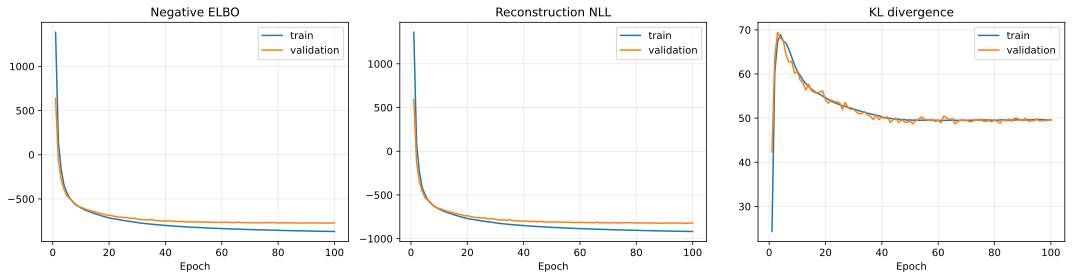

In [13]:
def plot_history(history):
    epochs_axis = np.arange(1, len(history['train_elbo']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    curves = [
        ('elbo', 'Negative ELBO'),
        ('recon', 'Reconstruction NLL'),
        ('KLD', 'KL divergence'),
    ]

    for ax, (key, title) in zip(axes, curves):
        ax.plot(epochs_axis, history[f'train_{key}'], label='train')
        ax.plot(epochs_axis, history[f'val_{key}'], label='validation')
        ax.set_xlabel('Epoch')
        ax.set_title(title)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)


### Samples and Reconstructions


Samples generated from the prior:


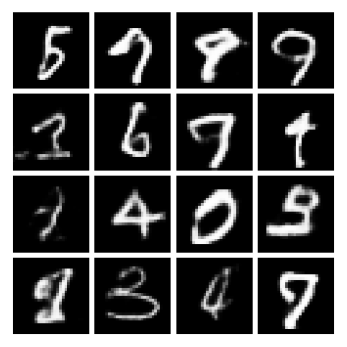

In [22]:
model.eval()

print('Samples generated from the prior:')
with torch.no_grad():
    generated = model.sample(16).cpu()
show_imgs(generated)

## Task 2


### Latent Traversals


In [23]:
def load_trained_vae_for_traversals():
    global model, latent_dim, model_is_trained

    checkpoint_file = os.path.join(CHECKPOINT_PATH, 'vae_model.pth')
    model_available = 'model' in globals() and isinstance(model, VAE)
    has_training_logs = model_available and len(getattr(model, 'logs', {}).get('test_elbo', [])) > 0

    if model_available and (globals().get('model_is_trained', False) or has_training_logs):
        model.eval()
        return model

    if os.path.exists(checkpoint_file):
        checkpoint = torch.load(checkpoint_file, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            latent_dim = checkpoint.get('latent_dim', 32)
            decoder_sigma = checkpoint.get('decoder_sigma', 0.1)
            model = VAE(latent_dim=latent_dim, decoder_sigma=decoder_sigma).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            latent_dim = globals().get('latent_dim', 32)
            model = VAE(latent_dim=latent_dim, decoder_sigma=0.1).to(device)
            model.load_state_dict(checkpoint)

        model_is_trained = True
        model.eval()
        print(f'Loaded trained VAE from {checkpoint_file}')
        return model

    raise RuntimeError(
        'Run the Task 1 training cell first, or make sure vae_model.pth exists in CHECKPOINT_PATH.'
    )


def first_index_for_digit(dataset, digit):
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        matches = (targets == digit).nonzero(as_tuple=True)[0]
        return int(matches[0].item())

    return next(i for i, label in enumerate(targets) if int(label) == digit)


def get_fixed_digit_pairs(dataset, digit_pairs):
    image_pairs = []
    label_pairs = []

    for digit_a, digit_b in digit_pairs:
        idx_a = first_index_for_digit(dataset, digit_a)
        idx_b = first_index_for_digit(dataset, digit_b)
        img_a, label_a = dataset[idx_a]
        img_b, label_b = dataset[idx_b]

        assert int(label_a) != int(label_b)
        image_pairs.append((img_a, img_b))
        label_pairs.append((int(label_a), int(label_b)))

    return image_pairs, label_pairs


model = load_trained_vae_for_traversals()
model.eval()

num_steps = 10
digit_pairs = [(0, 1), (3, 8), (4, 9)]
alphas = torch.linspace(0, 1, num_steps, device=device)
image_pairs, label_pairs = get_fixed_digit_pairs(test_set, digit_pairs)

latent_rows = []
pixel_rows = []

with torch.no_grad():
    for img_a, img_b in image_pairs:
        x_a = img_a.unsqueeze(0).to(device)
        x_b = img_b.unsqueeze(0).to(device)

        q_a, _, _ = model.encode(x_a)
        q_b, _, _ = model.encode(x_b)
        z_a = q_a.rsample()
        z_b = q_b.rsample()

        alpha_z = alphas.view(num_steps, 1)
        z_path = (1 - alpha_z) * z_a + alpha_z * z_b
        latent_path = model.decode(z_path)

        alpha_x = alphas.view(num_steps, 1, 1, 1)
        pixel_path = (1 - alpha_x) * x_a + alpha_x * x_b

        latent_rows.append(latent_path.cpu())
        pixel_rows.append(pixel_path.cpu())

latent_traversals = torch.stack(latent_rows)
pixel_traversals = torch.stack(pixel_rows)

assert all(a != b for a, b in label_pairs)
assert latent_traversals.shape == (3, num_steps, 1, 28, 28)
assert pixel_traversals.shape == (3, num_steps, 1, 28, 28)
assert latent_traversals.min().item() >= 0.0 and latent_traversals.max().item() <= 1.0

print('Selected digit pairs:', label_pairs)
print('Latent traversal shape:', tuple(latent_traversals.shape))
print('Pixel traversal shape:', tuple(pixel_traversals.shape))


Selected digit pairs: [(0, 1), (3, 8), (4, 9)]
Latent traversal shape: (3, 10, 1, 28, 28)
Pixel traversal shape: (3, 10, 1, 28, 28)


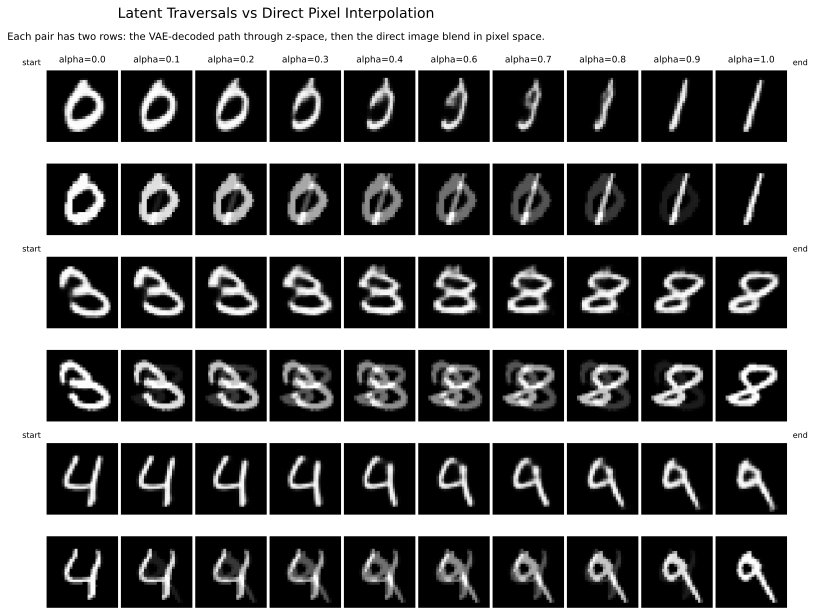

In [24]:
def plot_latent_and_pixel_traversals(latent_traversals, pixel_traversals, label_pairs, alphas):
    num_pairs, num_steps = latent_traversals.shape[:2]
    fig, axes = plt.subplots(
        2 * num_pairs,
        num_steps,
        figsize=(1.45 * num_steps, 1.45 * 2 * num_pairs),
    )

    row_descriptions = {
        'latent': 'latent space: decode((1-alpha) z1 + alpha z2)',
        'pixel': 'pixel space: (1-alpha) x1 + alpha x2',
    }

    for pair_idx, (digit_a, digit_b) in enumerate(label_pairs):
        latent_row = 2 * pair_idx
        pixel_row = latent_row + 1

        for step_idx in range(num_steps):
            axes[latent_row, step_idx].imshow(
                latent_traversals[pair_idx, step_idx, 0], cmap='gray', vmin=0, vmax=1
            )
            axes[pixel_row, step_idx].imshow(
                pixel_traversals[pair_idx, step_idx, 0], cmap='gray', vmin=0, vmax=1
            )

            axes[latent_row, step_idx].axis('off')
            axes[pixel_row, step_idx].axis('off')

            if pair_idx == 0:
                axes[latent_row, step_idx].set_title(
                    f'alpha={alphas[step_idx].item():.1f}', fontsize=9, pad=8
                )

        axes[latent_row, 0].set_ylabel(
            f'{digit_a} -> {digit_b}\n{row_descriptions["latent"]}',
            rotation=0,
            labelpad=108,
            va='center',
            ha='right',
            fontsize=9,
        )
        axes[pixel_row, 0].set_ylabel(
            f'{digit_a} -> {digit_b}\n{row_descriptions["pixel"]}',
            rotation=0,
            labelpad=108,
            va='center',
            ha='right',
            fontsize=9,
        )

        axes[latent_row, 0].text(
            -0.08, 1.05, 'start', transform=axes[latent_row, 0].transAxes,
            ha='right', va='bottom', fontsize=8
        )
        axes[latent_row, -1].text(
            1.08, 1.05, 'end', transform=axes[latent_row, -1].transAxes,
            ha='left', va='bottom', fontsize=8
        )

    fig.suptitle(
        'Latent Traversals vs Direct Pixel Interpolation',
        fontsize=14,
        y=0.995,
    )
    fig.text(
        0.5,
        0.955,
        'Each pair has two rows: the VAE-decoded path through z-space, then the direct image blend in pixel space.',
        ha='center',
        va='top',
        fontsize=10,
    )
    plt.subplots_adjust(left=0.28, right=0.99, top=0.90, bottom=0.03, wspace=0.04, hspace=0.18)
    plt.show()


plot_latent_and_pixel_traversals(latent_traversals, pixel_traversals, label_pairs, alphas.cpu())


## Task 3

### Inpainting Setup


In [25]:
def load_trained_vae_for_inpainting():
    global model, latent_dim, model_is_trained

    checkpoint_file = os.path.join(CHECKPOINT_PATH, 'vae_model.pth')
    model_available = 'model' in globals() and isinstance(model, VAE)
    has_training_logs = model_available and len(getattr(model, 'logs', {}).get('test_elbo', [])) > 0

    if model_available and (globals().get('model_is_trained', False) or has_training_logs):
        model.eval()
    elif os.path.exists(checkpoint_file):
        checkpoint = torch.load(checkpoint_file, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            latent_dim = checkpoint.get('latent_dim', 32)
            decoder_sigma = checkpoint.get('decoder_sigma', 0.1)
            model = VAE(latent_dim=latent_dim, decoder_sigma=decoder_sigma).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            latent_dim = globals().get('latent_dim', 32)
            model = VAE(latent_dim=latent_dim, decoder_sigma=0.1).to(device)
            model.load_state_dict(checkpoint)

        model_is_trained = True
        model.eval()
        print(f'Loaded trained VAE from {checkpoint_file}')
    else:
        raise RuntimeError(
            'Run the Task 1 training cell first, or make sure vae_model.pth exists in CHECKPOINT_PATH.'
        )

    for parameter in model.parameters():
        parameter.requires_grad_(False)

    return model


def first_index_for_label(dataset, label):
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        matches = (targets == label).nonzero(as_tuple=True)[0]
        return int(matches[0].item())

    return next(i for i, target in enumerate(targets) if int(target) == label)


def select_fixed_inpainting_images(dataset, labels=(0, 1, 2, 3, 4, 5)):
    images = []
    selected_labels = []

    for label in labels:
        idx = first_index_for_label(dataset, label)
        image, actual_label = dataset[idx]
        images.append(image)
        selected_labels.append(int(actual_label))

    return torch.stack(images), selected_labels


def make_top_half_mask(batch_size=1):
    mask = torch.zeros(batch_size, 1, 28, 28, device=device)
    mask[:, :, :14, :] = 1.0
    return mask


model = load_trained_vae_for_inpainting()
x_gt, inpaint_labels = select_fixed_inpainting_images(test_set)
x_gt = x_gt.to(device)
mask = make_top_half_mask(batch_size=1)
observed_display = mask * x_gt + (1 - mask) * 0.5

assert x_gt.shape == (6, 1, 28, 28)
assert mask.shape == (1, 1, 28, 28)
assert torch.allclose(mask[:, :, :14, :], torch.ones_like(mask[:, :, :14, :]))
assert torch.allclose(mask[:, :, 14:, :], torch.zeros_like(mask[:, :, 14:, :]))
assert not any(parameter.requires_grad for parameter in model.parameters())

print('Selected labels:', inpaint_labels)
print('Images shape:', tuple(x_gt.shape))
print('Mask shape:', tuple(mask.shape))


Selected labels: [0, 1, 2, 3, 4, 5]
Images shape: (6, 1, 28, 28)
Mask shape: (1, 1, 28, 28)


### Plotting Helpers


In [26]:
def plot_inpainting_results(method_name, observed, ground_truth, result, labels):
    num_examples = ground_truth.size(0)
    fig, axes = plt.subplots(num_examples, 3, figsize=(6.2, 1.55 * num_examples))
    column_titles = ['Observed top half', 'Ground truth', 'Inpainted result']

    observed = observed.detach().cpu()
    ground_truth = ground_truth.detach().cpu()
    result = result.detach().cpu().clamp(0, 1)

    for col_idx, title in enumerate(column_titles):
        axes[0, col_idx].set_title(title, fontsize=10)

    for row_idx in range(num_examples):
        row_images = [observed[row_idx], ground_truth[row_idx], result[row_idx]]
        for col_idx, image in enumerate(row_images):
            axes[row_idx, col_idx].imshow(image[0], cmap='gray', vmin=0, vmax=1)
            axes[row_idx, col_idx].axis('off')

        axes[row_idx, 0].set_ylabel(
            f'label {labels[row_idx]}', rotation=0, labelpad=28, va='center', fontsize=9
        )

    fig.suptitle(method_name, fontsize=13, y=0.995)
    plt.subplots_adjust(left=0.16, right=0.98, top=0.93, bottom=0.02, wspace=0.06, hspace=0.14)
    plt.show()


def plot_method_a_snapshots(snapshot_dict, labels):
    iterations = list(snapshot_dict.keys())
    num_examples = next(iter(snapshot_dict.values())).size(0)
    fig, axes = plt.subplots(num_examples, len(iterations), figsize=(1.25 * len(iterations), 1.35 * num_examples))

    for col_idx, iteration in enumerate(iterations):
        axes[0, col_idx].set_title(f'iter {iteration}', fontsize=9)

    for row_idx in range(num_examples):
        for col_idx, iteration in enumerate(iterations):
            image = snapshot_dict[iteration][row_idx].detach().cpu().clamp(0, 1)
            axes[row_idx, col_idx].imshow(image[0], cmap='gray', vmin=0, vmax=1)
            axes[row_idx, col_idx].axis('off')

        axes[row_idx, 0].set_ylabel(
            f'label {labels[row_idx]}', rotation=0, labelpad=28, va='center', fontsize=9
        )

    fig.suptitle('Method (a) snapshots: encode-decode with clamping', fontsize=13, y=0.995)
    plt.subplots_adjust(left=0.16, right=0.98, top=0.91, bottom=0.02, wspace=0.04, hspace=0.12)
    plt.show()


def plot_inpainting_losses(map_losses, pixel_losses):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

    axes[0].plot(map_losses)
    axes[0].set_title('Method (b): MAP latent loss')
    axes[0].set_xlabel('Optimization step')
    axes[0].set_ylabel('Average loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(pixel_losses)
    axes[1].set_title('Method (c): pixel negative ELBO')
    axes[1].set_xlabel('Optimization step')
    axes[1].set_ylabel('Average loss')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


### Method (a): Iterative Encode-Decode With Clamping


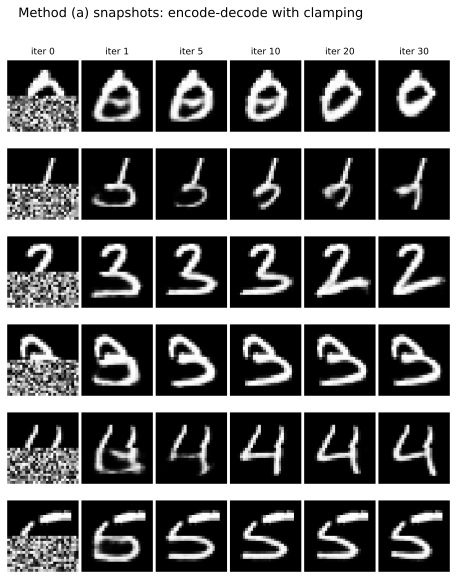

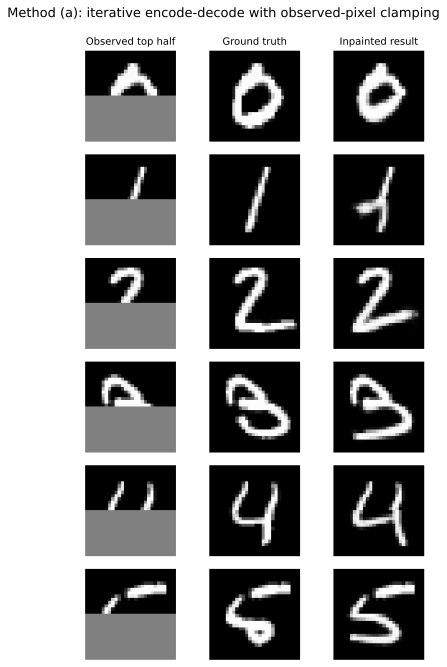

In [27]:
def inpaint_iterative_encode_decode(model, x, mask, num_iterations=30, snapshot_iterations=(0, 1, 5, 10, 20, 30)):
    snapshot_iterations = set(snapshot_iterations)
    snapshots = {}

    with torch.no_grad():
        x_t = mask * x + (1 - mask) * torch.rand_like(x)
        if 0 in snapshot_iterations:
            snapshots[0] = x_t.detach().cpu()

        for iteration in range(1, num_iterations + 1):
            q_z_given_x, _, _ = model.encode(x_t)
            z_t = q_z_given_x.rsample()
            decoded = model.decode(z_t)
            x_t = mask * x + (1 - mask) * decoded

            if iteration in snapshot_iterations:
                snapshots[iteration] = x_t.detach().cpu()

    return x_t.detach().clamp(0, 1), snapshots


method_a_result, method_a_snapshots = inpaint_iterative_encode_decode(model, x_gt, mask)

assert method_a_result.shape == x_gt.shape
assert method_a_result.min().item() >= 0.0 and method_a_result.max().item() <= 1.0
assert all(snapshot.shape == x_gt.shape for snapshot in method_a_snapshots.values())

plot_method_a_snapshots(method_a_snapshots, inpaint_labels)
plot_inpainting_results(
    'Method (a): iterative encode-decode with observed-pixel clamping',
    observed_display,
    x_gt,
    method_a_result,
    inpaint_labels,
)


### Method (b): MAP Estimate of z by Gradient Descent


MAP latent optimization:   0%|          | 0/500 [00:00<?, ?it/s]

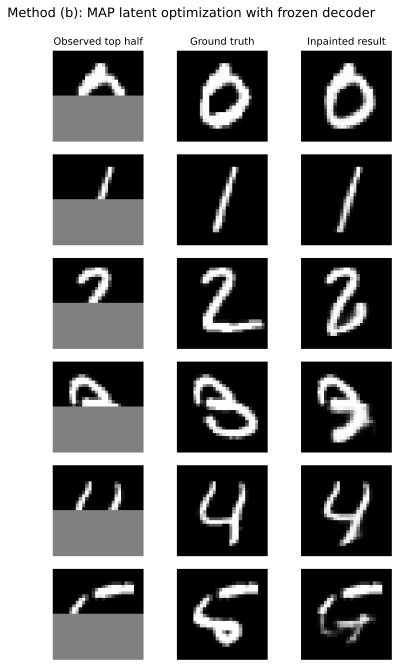

In [31]:
def inpaint_map_latent(model, x, mask, num_steps=500, lr=0.05):
    z = torch.randn(x.size(0), model.latent_dim, device=x.device, requires_grad=True)
    optimizer = optim.Adam([z], lr=lr)
    sigma = model.decoder_sigma
    losses = []

    for step in tqdm(range(num_steps), leave=False, desc='MAP latent optimization'):
        optimizer.zero_grad()
        decoded = model.decode(z)
        reconstruction_term = 0.5 / (sigma ** 2) * (((decoded - x) * mask) ** 2).flatten(1).sum(dim=1)
        prior_term = 0.5 * (z ** 2).sum(dim=1)
        per_example_loss = reconstruction_term + prior_term
        loss = per_example_loss.mean()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        decoded = model.decode(z)
        result = mask * x + (1 - mask) * decoded

    return result.detach().clamp(0, 1), losses


method_b_result, method_b_losses = inpaint_map_latent(model, x_gt, mask)

assert method_b_result.shape == x_gt.shape
assert method_b_result.min().item() >= 0.0 and method_b_result.max().item() <= 1.0
assert len(method_b_losses) == 500

plot_inpainting_results(
    'Method (b): MAP latent optimization with frozen decoder',
    observed_display,
    x_gt,
    method_b_result,
    inpaint_labels,
)


### Method (c): Optimize Missing Pixels by Negative ELBO


Pixel optimization:   0%|          | 0/500 [00:00<?, ?it/s]

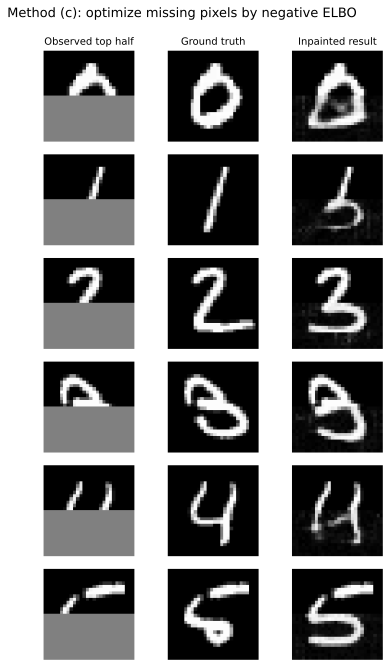

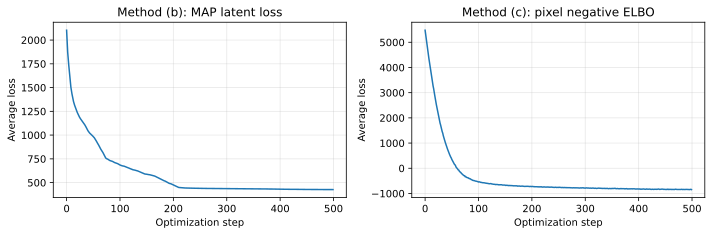

In [32]:
def inpaint_optimize_pixels(model, x, mask, num_steps=500, lr=0.05):
    init_free_pixels = torch.rand_like(x).clamp(1e-4, 1 - 1e-4)
    y = torch.logit(init_free_pixels).detach().requires_grad_(True)
    optimizer = optim.Adam([y], lr=lr)
    losses = []

    for step in tqdm(range(num_steps), leave=False, desc='Pixel optimization'):
        optimizer.zero_grad()
        x_free = torch.sigmoid(y)
        x_current = mask * x + (1 - mask) * x_free
        loss = model.calc_elbo(x_current)[0]
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        result = mask * x + (1 - mask) * torch.sigmoid(y)

    return result.detach().clamp(0, 1), losses


method_c_result, method_c_losses = inpaint_optimize_pixels(model, x_gt, mask)

assert method_c_result.shape == x_gt.shape
assert method_c_result.min().item() >= 0.0 and method_c_result.max().item() <= 1.0
assert len(method_c_losses) == 500

plot_inpainting_results(
    'Method (c): optimize missing pixels by negative ELBO',
    observed_display,
    x_gt,
    method_c_result,
    inpaint_labels,
)
plot_inpainting_losses(method_b_losses, method_c_losses)


### Comparison

Method (a) is a fast heuristic: it repeatedly projects the current image through the encoder and decoder, then clamps the observed top pixels back to the true values. It often gives plausible VAE-like bottoms, but because each pass uses the encoder and a posterior sample, the result can drift or become noisy.

Method (b) searches directly in the latent space. The reconstruction term forces the decoded image to match the observed top half, while the prior term keeps the latent vector near a typical VAE latent code. This tends to produce coherent samples from the model manifold, but it may miss details if the best latent explanation of the top half is not unique or if optimization reaches a local minimum.

Method (c) optimizes the missing pixels themselves under the VAE negative ELBO. It has more freedom than method (b), so it can fit the surrogate objective strongly, but the optimum of this objective is not necessarily the visually best inpainting. It can also find local optima or exploit weaknesses of the encoder/decoder objective instead of producing a natural digit bottom.
